In [ ]:
import random
import numpy as np
import pandas as pd
from numpy.random import randn, randint
from scipy.linalg import norm
import matplotlib.pyplot as plt

# **Least square regression**

In [ ]:
# generate random data matrix
random.seed(1)
n = 6  # number of data points
d = 4  # number of features
A = randn(n,d)

# optional: give it linearly dependent columns
# A[:,3] = A[:,2]

In [ ]:
# form data from noiseless linear model
random.seed(1)
wtrue = randn(d)
b = A.dot(wtrue)

# # form data from noisy linear model
# wtrue = randn(d)
# b = A.dot(wtrue) + .1*randn(n)

In [ ]:
# look at least squares objective as a function of w
# f(wx) = ||Ax - b||^2, ∇f(x) = 2A^T(AX-B) = 2A^TAX - 2A^Tb
def f_LS(x):
    return norm(b - A.dot(x))**2

def gradf_LS(x):
    #print(A.T @ (A @ x) - 2*A.T @ b)
    return 2*A.T @ (A @ x) - 2*A.T @ b

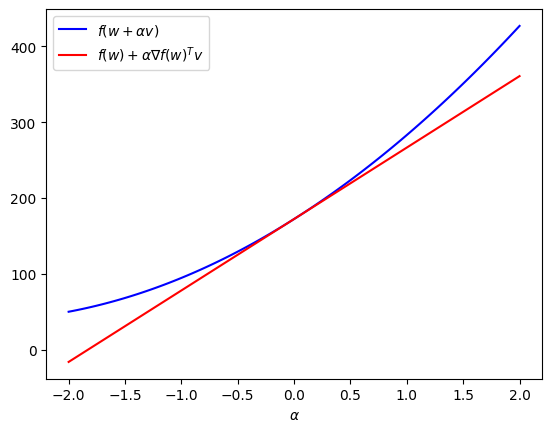

In [ ]:
# gradient at w provides an approximation of f near w
# We cannot visualize the approximation when the dimension of the function domain is > 1
# We retrict the function onto 1-d subspaces to visualize it
w = randn(d)  # any base point
v = randn(d)  # any 1-d direction we want to examine
alphas = np.linspace(-2,2,100)
plt.plot(alphas, [f_LS(w + alpha*v) for alpha in alphas], color='b',
     label=r"$f(w + \alpha v)$")   # blue curve --- the orignal function along the direction of v
plt.plot(alphas, [f_LS(w) + alpha*gradf_LS(w).dot(v) for alpha in alphas], color='r',
      label=r"$f(w) + \alpha \nabla f(w)^T v$")   # red curve --- the linear approximation (built using gradient) of f along the direction of v
plt.xlabel(r"$\alpha$")
plt.legend()

In [ ]:
"""This function implements gradient descent for the function f with gradient ∇f"""
def gradient_descent(f, gradf,
                     x_init,         # initialization
                     alpha = 0.1,      # small constant step size - try other values!
                     maxiters = 100    # maximum number of iterations
                     ):
    grad_norms = []  # a list to record all the gradient norms we see
    x = x_init
    grad_norms.append(norm(gradf(x))) # record the initial gradient norm

    # start descending!
    for k in range(maxiters):
        x = x - alpha*gradf(x)       # take a gradient step
        grad_norms.append(norm(gradf(x)))             # record its value
    return x, grad_norms

## Part (a) running gradient descent with different stepsizes

### learning rate = 1

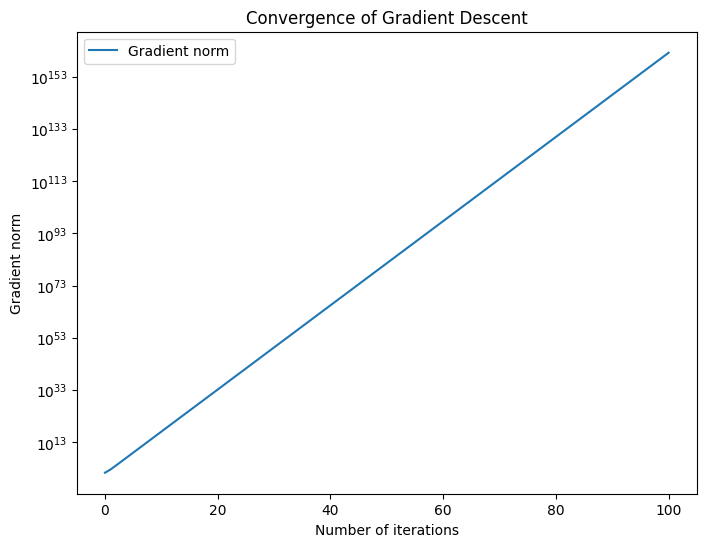

In [ ]:
# Running gradient descent on f_LS and plot the square error (function value)
x, grad_norms = gradient_descent(f_LS, gradf_LS, randn(d), alpha = 1, maxiters=100)  # we take stepsize = 0.02
plt.figure(figsize=(8,6))
plt.semilogy(grad_norms, label="Gradient norm")
plt.xlabel("Number of iterations")
plt.ylabel("Gradient norm")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.show()


### learning rate = 0.1

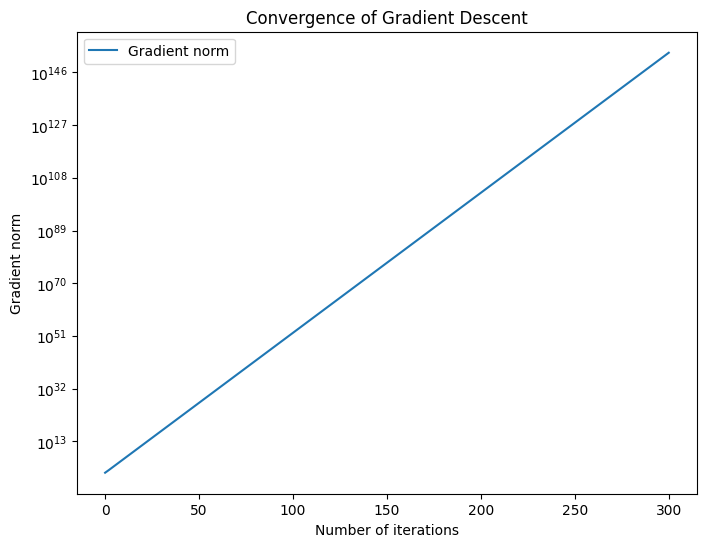

In [ ]:
# Running gradient descent on f_LS and plot the square error (function value)
x, grad_norms = gradient_descent(f_LS, gradf_LS, randn(d), alpha = 0.1, maxiters=300)
plt.figure(figsize=(8,6))
plt.semilogy(grad_norms, label="Gradient norm")
plt.xlabel("Number of iterations")
plt.ylabel("Gradient norm")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.show()

### learning rate = 0.01

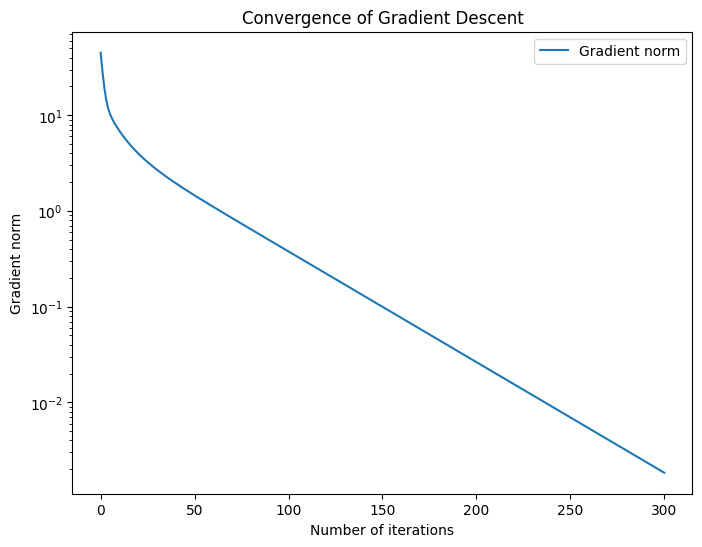

In [ ]:
# Running gradient descent on f_LS and plot the square error (function value)
x, grad_norms = gradient_descent(f_LS, gradf_LS, randn(d), alpha = 0.01, maxiters=300)  # we take stepsize = 0.02
plt.figure(figsize=(8,6))
plt.semilogy(grad_norms, label="Gradient norm")
plt.xlabel("Number of iterations")
plt.ylabel("Gradient norm")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.show()

### learnig rate = 0.05

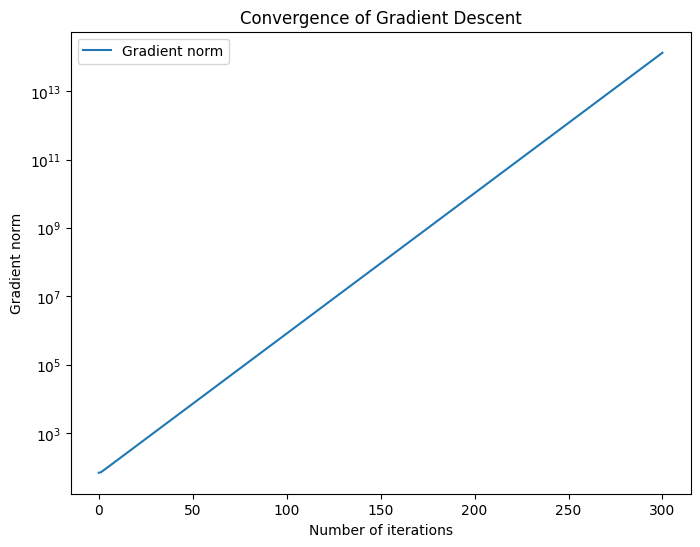

In [ ]:
# Running gradient descent on f_LS and plot the square error (function value)
x, grad_norms = gradient_descent(f_LS, gradf_LS, randn(d), alpha = 0.05, maxiters=300)  # we take stepsize = 0.02
plt.figure(figsize=(8,6))
plt.semilogy(grad_norms, label="Gradient norm")
plt.xlabel("Number of iterations")
plt.ylabel("Gradient norm")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.show()

## Doing it with higher dimensions now

In [ ]:
# generate random data matrix
random.seed(1)
n = 100  # number of data points
d = 20  # number of features
A = randn(n,d)

# optional: give it linearly dependent columns
# A[:,3] = A[:,2]

In [ ]:
# form data from noiseless linear model
random.seed(1)
wtrue = randn(d)
b = A.dot(wtrue)

## learning rate = 1

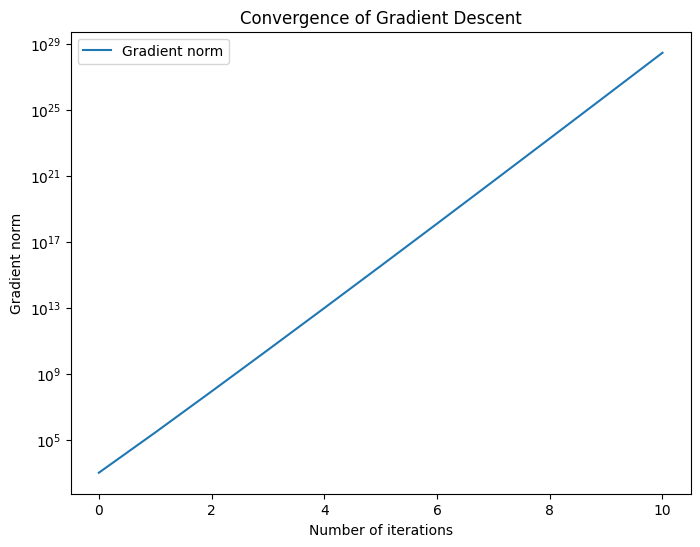

In [ ]:
# Running gradient descent on f_LS and plot the square error (function value)
x, grad_norms = gradient_descent(f_LS, gradf_LS, randn(d), alpha = 1, maxiters=10)  # we take stepsize = 0.02
plt.figure(figsize=(8,6))
plt.semilogy(grad_norms, label="Gradient norm")
plt.xlabel("Number of iterations")
plt.ylabel("Gradient norm")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.show()


### learning rate = 0.1

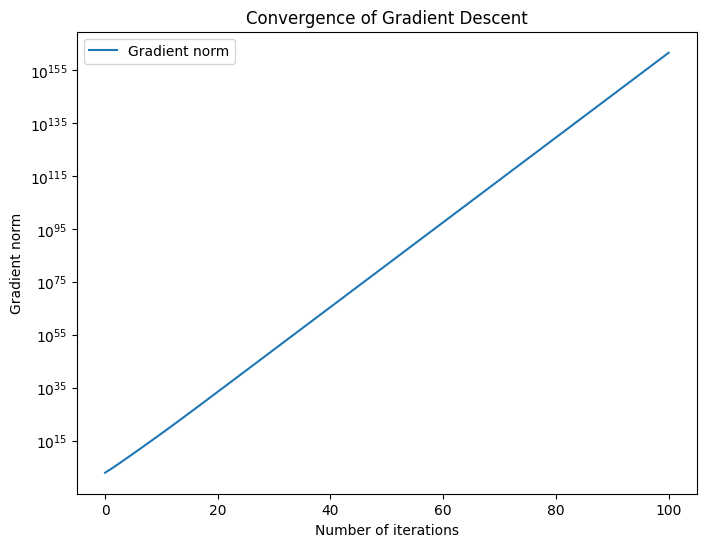

In [ ]:
# Running gradient descent on f_LS and plot the square error (function value)
x, grad_norms = gradient_descent(f_LS, gradf_LS, randn(d), alpha = 0.1, maxiters=100)
plt.figure(figsize=(8,6))
plt.semilogy(grad_norms, label="Gradient norm")
plt.xlabel("Number of iterations")
plt.ylabel("Gradient norm")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.show()

### learning rate = 0.01

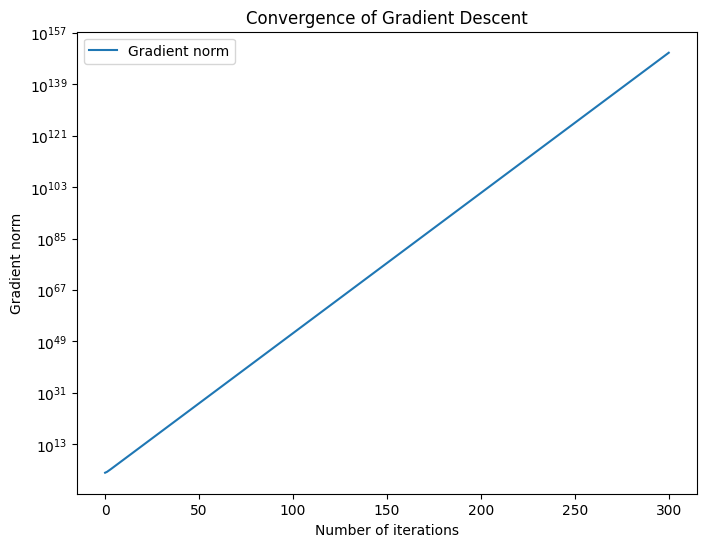

In [ ]:
# Running gradient descent on f_LS and plot the square error (function value)
x, grad_norms = gradient_descent(f_LS, gradf_LS, randn(d), alpha = 0.01, maxiters=300)  # we take stepsize = 0.02
plt.figure(figsize=(8,6))
plt.semilogy(grad_norms, label="Gradient norm")
plt.xlabel("Number of iterations")
plt.ylabel("Gradient norm")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.show()

### learnig rate = 0.05

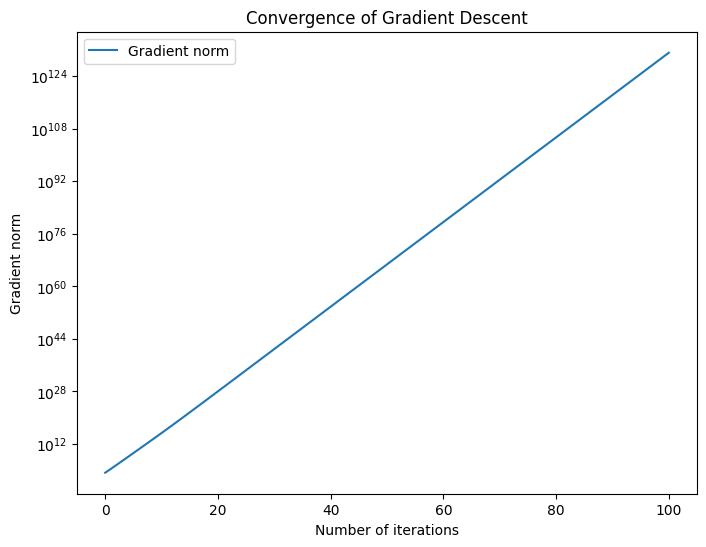

In [ ]:
# Running gradient descent on f_LS and plot the square error (function value)
x, grad_norms = gradient_descent(f_LS, gradf_LS, randn(d), alpha = 0.05, maxiters=100)  # we take stepsize = 0.02
plt.figure(figsize=(8,6))
plt.semilogy(grad_norms, label="Gradient norm")
plt.xlabel("Number of iterations")
plt.ylabel("Gradient norm")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.show()

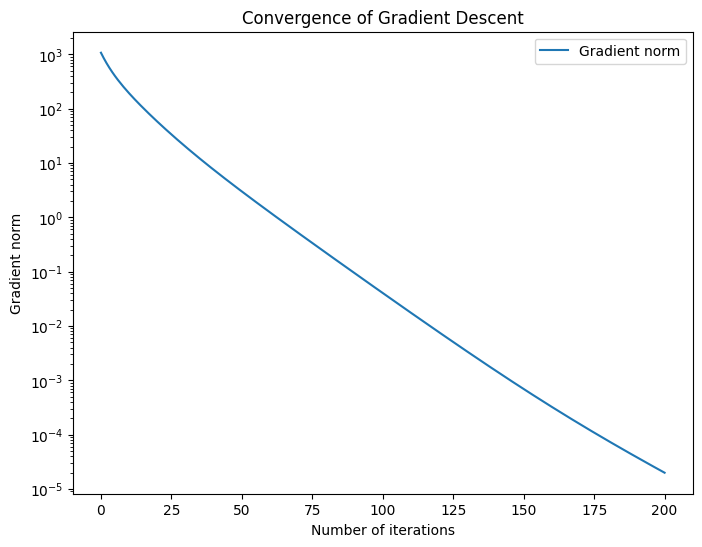

In [ ]:
x, grad_norms = gradient_descent(f_LS, gradf_LS, randn(d), alpha = 0.001, maxiters=200)  # we take stepsize = 0.02
plt.figure(figsize=(8,6))
plt.semilogy(grad_norms, label="Gradient norm")
plt.xlabel("Number of iterations")
plt.ylabel("Gradient norm")
plt.title("Convergence of Gradient Descent")
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Answer to Question A

We can see that using different stepsizes in the gradient descent process in the loss function of the least squares objective function has pretty different results when it comes to minimizing the function. We can see that when a stepsize of $1$ is used the overall algorithm overstep and the gradient norm increases, meaning that the we went past the local minimum and now we moving up the function. We can see that the stepsize of $0.01$ moves against the minimum gradient norm but takes more iterations to get close to the minimum. The optimal stepsizes are either $0.05$ or $0.1$ as the algorithm converges really fast and ends getting really close to minimum gradient values.

When I changed the dimensions to more features and samples, I realized that tne gradient descent algorithms with stepsizes $0.1, 1, 0.01$ diverged to infinity fast. I then realized that the optimal stepsize for this dimension was way smaller, $0.001$, this can be explain by the complex geometry of the multidimensional loss function.

# **A systematic way to select stepsize --- backtracking linesearch**




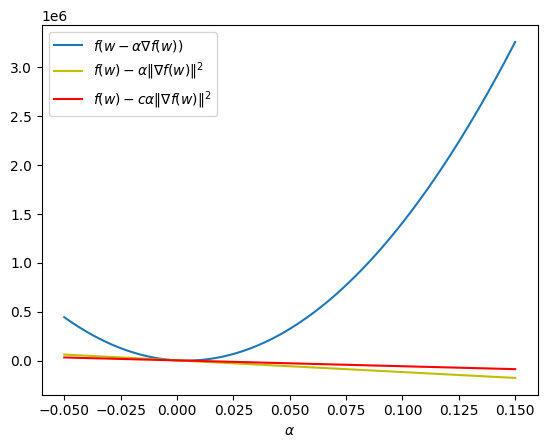

In [ ]:
# We fix a w and check f(w - alpha*∇f(w)) for different choice of stepsize
# We compare it with the linear approximation
random.seed(1)

w = randn(d)
g = gradf_LS(w)
c = .5
alphas = .05*np.linspace(-1,3,100)
plt.plot(alphas, [f_LS(w - alpha*g) for alpha in alphas],
     label = r"$f(w - \alpha \nabla f(w))$")                    # Actual function value
plt.plot(alphas, [f_LS(w) - alpha*norm(g)**2 for alpha in alphas],color='y',  # linear approximation
         label=r"$f(w) - \alpha \|\nabla f(w)\|^2$")
plt.plot(alphas, [f_LS(w) - c*alpha*norm(g)**2 for alpha in alphas],color='r', # Armijo sufficient decrease, which is provably guaranteed to be above the actual function value for small positive alpha
         label=r"$f(w) - c\alpha \|\nabla f(w)\|^2$")
plt.xlabel(r"$\alpha$")
plt.legend()
plt.show()

We can observe in this diagram that the optimal stepsize is really small and close to $0$. This makes sense with the previous findings that we had when it came to more complex dimensions in the least squares problem.

In [ ]:
"""This function implements gradient descent with linesearch for the function f with gradient ∇f"""
def gradient_descent_linesearch(f, gradf,
                                x_init,        # initialization
                                alpha = 1,      # initial step size - try other values!
                                maxiters = 100,   # maximum number of iterations
                                c = .5            # Armijo sufficient decrease
                                ):

    grad_norms = []  # a list to record all the gradient norms we see
    x = x_init
    fx = f(x)
    g = gradf(x)
    grad_norms.append(norm(g)) # record the initial value
    alpha0 = alpha
    # start descending!
    for k in range(maxiters):
        x_new = x - alpha*g      # take a gradient step
        fx_new = f(x_new)
        while fx_new > fx - c*alpha*norm(g)**2:
            alpha /= 2
            x_new = x - alpha*g      # take a gradient step
            fx_new = f(x_new)
        x, fx, g = x_new, fx_new, gradf(x_new)
        alpha = alpha0
        grad_norms.append(norm(g))
    return w, grad_norms

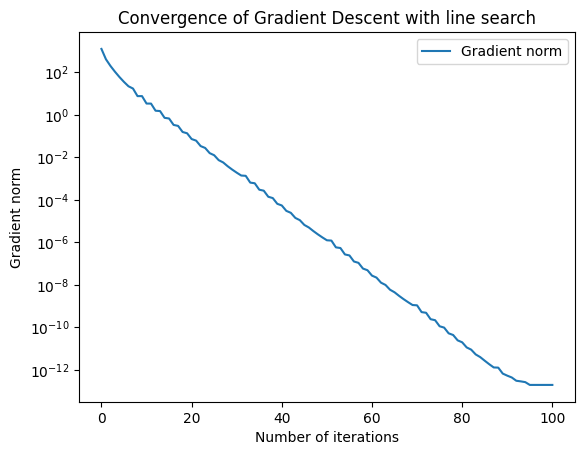

In [ ]:
# running gradient descent with linesearch

x, grad_norms = gradient_descent_linesearch(f_LS, gradf_LS, randn(d), alpha = 1, maxiters=100, c = .5)
plt.semilogy(grad_norms, label="Gradient norm")
plt.xlabel("Number of iterations")
plt.ylabel("Gradient norm")
plt.title("Convergence of Gradient Descent with line search")
plt.legend()
plt.show()

We can see that despite the initial stepsize value being $1$, the backtracking linesearch algorithm ensures that we find the proper stepsize at each step by looking ahead and ensuring we dont overshoot with our stepsize.

In [ ]:
###### For assignemnt 2 #################
########### function 1 ###################
def f_1(x):
    return x[0]**2 + 400*(x[1]**2)

def grad_1(x):
    """
    Gradient of the quadratic function.
    Returns:
        numpy array of shape (2,)
    """
    return np.array([2*x[0], 800*x[1]])

########### function 2 ###################
def f_2(x):
    return 0.0001*(x[0] - 5)**2 + 0.0002*(x[1] -1)**2

def grad_2(x):
    """
    Gradient of the quadratic function.
    Returns:
        numpy array of shape (2,)
    """
    return np.array([0.0002*(x[0] - 5), 0.0004*(x[1]-1)])

########### function 3 ###################
def f_3(x):
  eps = 1e-4
  if abs(x) >= eps:
    return abs(x)
  else:
    return x**2/2/eps + eps/2

def grad_3(x):
  eps = 1e-4
  if abs(x) >= eps:
    return np.sign(x)
  else:
    return x/eps



## Gradient Descent with Stopping Criterion(Max Norm)

In [ ]:

"""This function implements gradient descent for the function f with gradient ∇f with gradient norm stopping criterion"""
def gradient_descent_max_norm(f, gradf,
                             x_init,              # initialization
                             alpha = 0.1,         # step size
                             maxiters = 100,      # maximum number of iterations
                             max_gradient= 1e-5           # max_gradient
                             ):
    grad_norms = []  # a list to record all the gradient norms we see
    x = x_init
    grad_norms.append(norm(gradf(x))) # record the initial gradient norm

    # start descending!
    for k in range(maxiters):
      if grad_norms[-1] < max_gradient:
        break
      x = x - alpha * gradf(x)       # take a gradient step
      grad_norms.append(norm(gradf(x)))             # record its value

    return x, grad_norms

## Gradient Descent with Stopping Criterion(Distance to solution)

In [ ]:
"""This function implements gradient descent for the function f with gradient ∇f with distance to optimal solution stopping criterion"""
def gradient_descent_minDsit(f, gradf,
                     x_init,              # initialization
                     optimal_solution,    # optimal solution to compare against
                     distance,            # distance threshold squared (stopping criterion)
                     alpha = 0.1,         # step size
                     maxiters = 100       # maximum number of iterations
                     ):
    grad_norms = []  # a list to record all the gradient norms we see
    x = x_init
    grad_norms.append(norm(gradf(x)))

    # start descending!
    for k in range(maxiters):
      diff = x - optimal_solution
      if diff.dot(diff) < distance:
        break
      else:
        x = x - alpha*gradf(x)       # take a gradient step
        grad_norms.append(norm(gradf(x)))             # record its value
    return x, grad_norms

## Part C: using gradient descent with linesearch and plotting this against the tolerance

In [ ]:

# solve for the linear squares problem in cells 2 - 4
x_star = np.linalg.pinv(A).dot(b)

def gd_linesearch_grad_norm(f, gradf, x_init, tolerance, alpha_init=1.0, c=0.5, beta=0.5, maxiters=5000):
    x = np.array(x_init, dtype=float)
    for k in range(maxiters):
        g = gradf(x)
        g_norm = norm(g)
        if g_norm < tolerance:
            return k
        alpha = alpha_init
        fx = f(x)
        while f(x - alpha * g) > fx - c * alpha * (g_norm**2):
            alpha *= beta
        x = x - alpha * g
    return maxiters

def gd_linesearch_dist_sol(f, gradf, x_init, x_opt, tolerance, alpha_init=1.0, c=0.5, beta=0.5, maxiters=5000):
    x = np.array(x_init, dtype=float)
    for k in range(maxiters):
        diff = x - x_opt
        if diff.dot(diff) < tolerance:
            return k
        g = gradf(x)
        g_norm = norm(g)
        alpha = alpha_init
        fx = f(x)
        while f(x - alpha * g) > fx - c * alpha * (g_norm**2):
            alpha *= beta
        x = x - alpha * g
    return maxiters

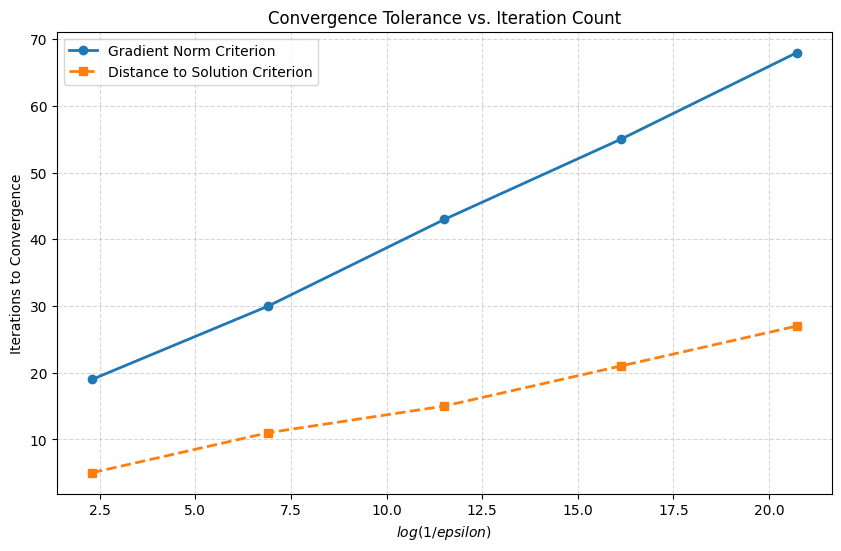

In [ ]:
# run against different values
tolerances = [1e-1, 1e-3, 1e-5, 1e-7, 1e-9]
#tolerances on the x axis log/ tolerance
x_log = [np.log(1/eps) for eps in tolerances]
np.random.seed(42)
x_init = randn(d)
iters_grad = []
iters_dist = []
for eps in tolerances:
  it_g = gd_linesearch_grad_norm(f_LS, gradf_LS, x_init, eps)
  it_d = gd_linesearch_dist_sol(f_LS, gradf_LS, x_init, x_star, eps)
  iters_grad.append(it_g)
  iters_dist.append(it_d)
# plotting the results
plt.figure(figsize=(10, 6))
plt.plot(x_log, iters_grad, 'o-', linewidth=2, label='Gradient Norm Criterion')
plt.plot(x_log, iters_dist, 's--', linewidth=2, label='Distance to Solution Criterion')
plt.xlabel('$log(1/epsilon)$')
plt.ylabel('Iterations to Convergence')
plt.title('Convergence Tolerance vs. Iteration Count')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()